In [14]:
import os
#from obspy.core import UTCDateTime
#from obspy.clients.fdsn import Client
from variables import *
from functions.get_data import get_data
from obspy import read
from obspy.signal import konnoohmachismoothing
import numpy as np

In [2]:
get_data()

File data/TO_PE50_20080820_190000.mseed already exists. Skipping download.


In [3]:
files = os.listdir(output_dir)
for file in files:
    print(file)
filename = os.path.join(output_dir,files[0])

TO_PE50_20080820_190000.mseed


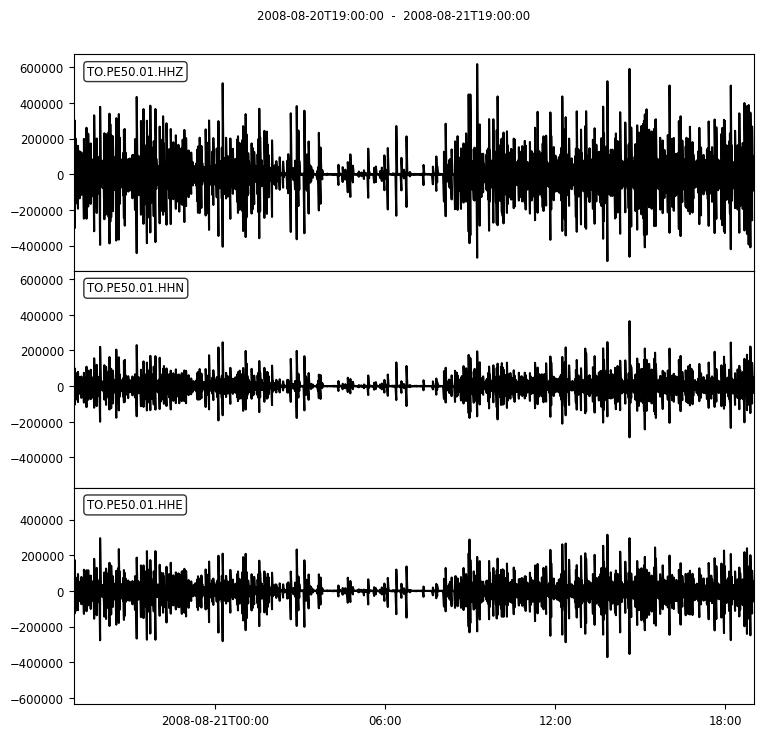

3 Trace(s) in Stream:
TO.PE50.01.HHE | 2008-08-20T19:00:00.000000Z - 2008-08-21T19:00:00.000000Z | 100.0 Hz, 8640001 samples
TO.PE50.01.HHN | 2008-08-20T19:00:00.000000Z - 2008-08-21T19:00:00.000000Z | 100.0 Hz, 8640001 samples
TO.PE50.01.HHZ | 2008-08-20T19:00:00.000000Z - 2008-08-21T19:00:00.000000Z | 100.0 Hz, 8640001 samples

In [4]:
st = read(filename)
_= st.plot()
st.detrend(type = 'demean')
st.detrend(type = 'linear')

In [5]:
tr = st.copy()
start_time = tr[0].stats.starttime
one_minute = 60
total_minutes = 24 * 60

slices = []

for i in range(total_minutes):
    slice_start = start_time + (i*one_minute)
    slice_end = slice_start + one_minute

    tr_slice = tr.slice(starttime = slice_start, endtime = slice_end)
    tr_slice.detrend(type = "demean")
    tr_slice.detrend(type = "linear")
    slices.append(tr_slice)
print(f"Successfully created {len(slices)} minute-long slices.")

Successfully created 1440 minute-long slices.


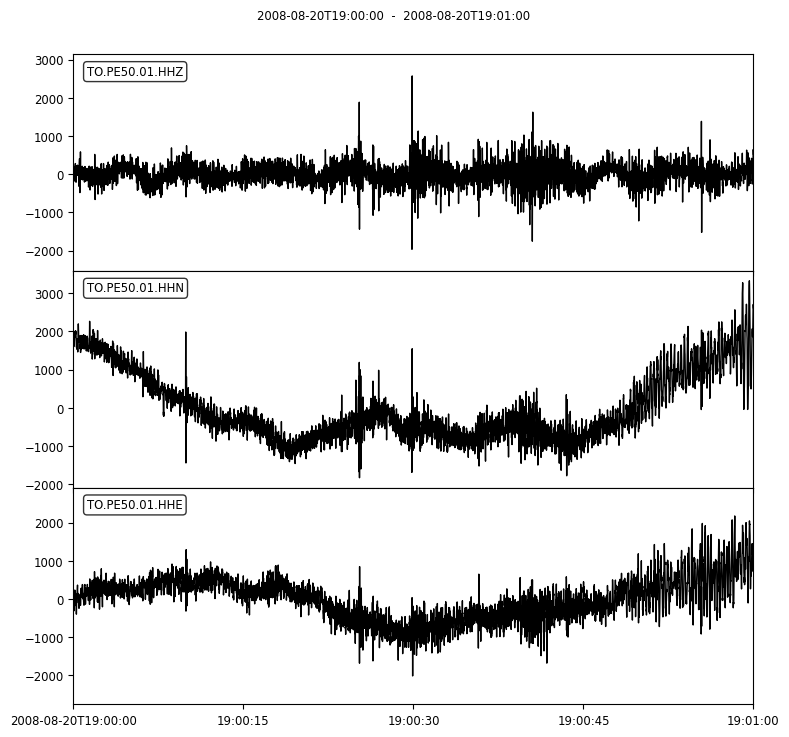

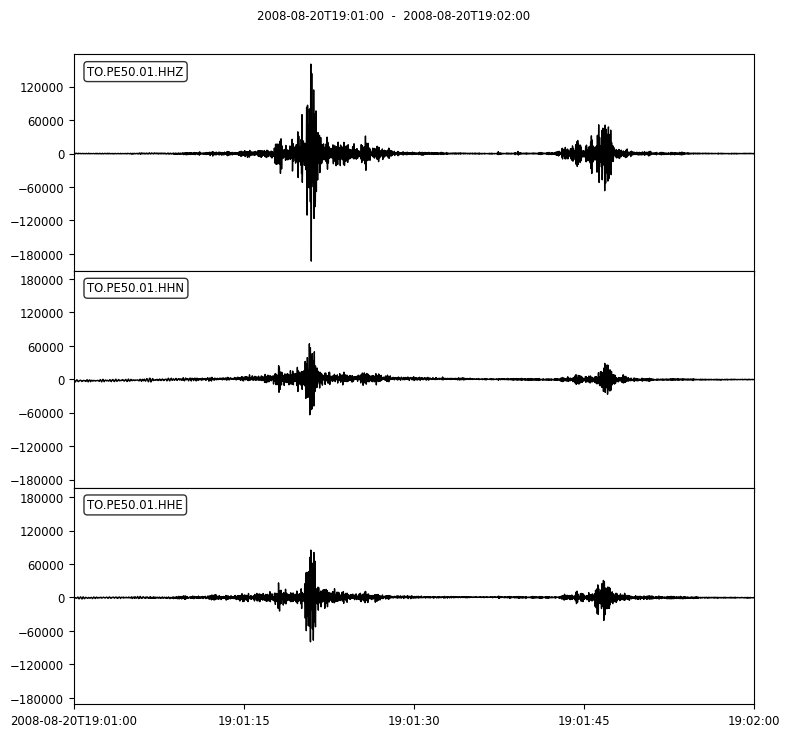

In [6]:
_ =slices[0].plot()
_ =slices[1].plot()

In [ ]:
from functions.filtering import sta_lta_window_rejection
from functions.filtering import reject_low_frequency_windows
#from functions.filtering import filter_windows_by_low_freq_power
filter1 = sta_lta_window_rejection(slices, lta_seconds=10)
filter2 = reject_low_frequency_windows(filter1, amplitude_ratio_threshold=2)
#filter_google = filter_windows_by_low_freq_power(filter1)
print("After applying filter 1:",len(filter1))
print("After applying filter 2:",len(filter2))

93
12


In [13]:
data = []
pp = filter2.copy()
for window in pp:
    window.filter("bandpass", freqmin = 0.1,freqmax = 20, corners = 4, zerophase = True)
    window.taper(max_percentage=0.05, type="cosine")
    data.append(window)
print(len(data))

12


In [30]:
def nextpow2(n, minimum_power_of_two=2**15):  # 2**15 = 32768
    power_of_two = minimum_power_of_two
    while True:
        if power_of_two > n:
            return power_of_two
        power_of_two *= 2
bwidth = 40
max_n_samples = data[0][-1].stats.npts
good_n = nextpow2(max_n_samples)
dt = data[0][-1].stats.delta
fft_frq = np.fft.rfftfreq(good_n, dt)
smoothMatrix = konnoohmachismoothing.calculate_smoothing_matrix(fft_frq, bandwidth= bwidth, normalize = True)

In [31]:
from numpy.fft import rfft
def total_horizontal_energy(ns, ew, settings=None):
    """Computes the magnitude of sum of two orthoginal vectors."""
    return np.sqrt((ns*ns + ew*ew))
waveforms = []
for window in data:
        #PROCESING
        #number_of_data_points = 200
        #center_frequencies_in_hz = np.geomspace(
        #                    min_frequency, max_frequency, number_of_data_points)
        fft_ns = np.abs(rfft(window[1].data, good_n))
        fft_ew = np.abs(rfft(window[0].data, good_n))
        h = total_horizontal_energy(fft_ns, fft_ew)
        v = np.abs(rfft(window[2].data, good_n))
        #SMOOTHING
        h_smooth = konnoohmachismoothing.apply_smoothing_matrix(h,smoothMatrix, count = 1)
        v_smooth = konnoohmachismoothing.apply_smoothing_matrix(v, smoothMatrix, count = 1)
        hvsr = h_smooth/v_smooth
        waveforms.append(hvsr)

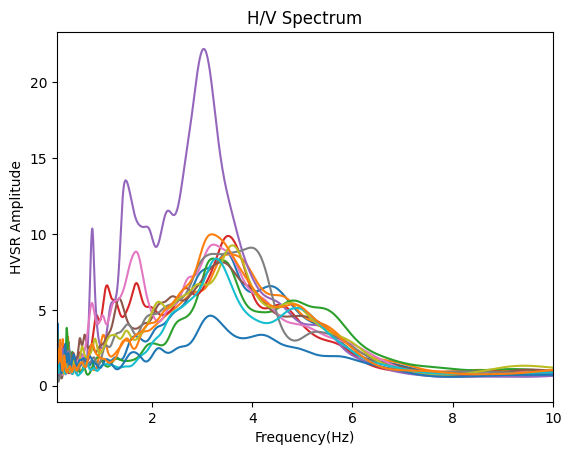

In [33]:
import matplotlib.pyplot as plt

for w in waveforms:
    plt.plot(fft_frq, w)
#plt.xlim(fmin,fmax)
plt.title("H/V Spectrum")
plt.xlabel('Frequency(Hz)')
plt.ylabel("HVSR Amplitude")
plt.xlim(0.1,10)
#plt.ylim(0,15)
plt.show()

In [34]:
from scipy.signal import find_peaks
mean_curve = np.mean(waveforms, axis = 0)
std_curve = np.std(waveforms, axis=0)

peak_indices, properties = find_peaks(mean_curve, distance=20)

if len(peak_indices) == 0:
    # Fallback if no distinct peak is found: take the absolute maximum
    max_idx = np.argmax(mean_curve)
else:
    # Find which of the local peaks is the absolute tallest
    max_idx = peak_indices[np.argmax(mean_curve[peak_indices])]

peak_freq = fft_frq[max_idx]
peak_amplitude = mean_curve[max_idx]

peak_error_amplitude = std_curve[max_idx] 
individual_peak_freqs = []

for curve in waveforms:
    ind_max_idx = np.argmax(curve)
    individual_peak_freqs.append(fft_frq[ind_max_idx])

freq_error = np.std(individual_peak_freqs)

# --- 5. PRINT RESULTS ---
print(f"--- Peak Estimation Results ---")
print(f"Dominant Peak Frequency : {peak_freq:.3f} Hz ± {freq_error:.3f} Hz")
print(f"Peak Amplitude (Value)  : {peak_amplitude:.3f} ± {peak_error_amplitude:.3f}")

--- Peak Estimation Results ---
Dominant Peak Frequency : 3.217 Hz ± 0.246 Hz
Peak Amplitude (Value)  : 8.845 ± 3.346


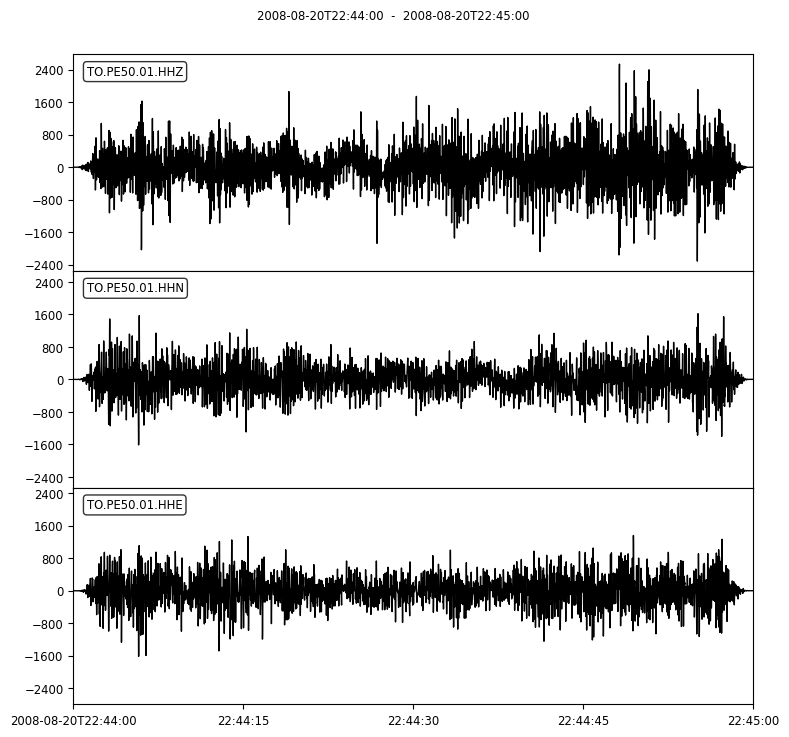

In [43]:
_ = data[0].plot()